<a href="https://colab.research.google.com/github/eduardoestacio-dot/Analise-de-Dados-PANDA/blob/main/Hip%C3%B3teses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJETO I

DADOS DE AVALIAÇÕES

In [ ]:
import pandas as pd

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

CALCULANDO O DESVIO PADRÃO

In [ ]:
desvio_padrao = df_techtaste['avaliacoes'].std()
print(f'Desvio padrão: {desvio_padrao:.2f}')


Desvio padrão: 6.42


CALCAULANDO ERRO PADRÃO AMOSTRAL DA MÉDIA

In [ ]:
from scipy import stats
from scipy.stats import sem

erro_padrao = stats.sem(df_techtaste['avaliacoes'])
print(f'Erro padrão amostral da média: {erro_padrao:.2f}')


Erro padrão amostral da média: 0.72


GRÁFICO DE HISTOGRAMA

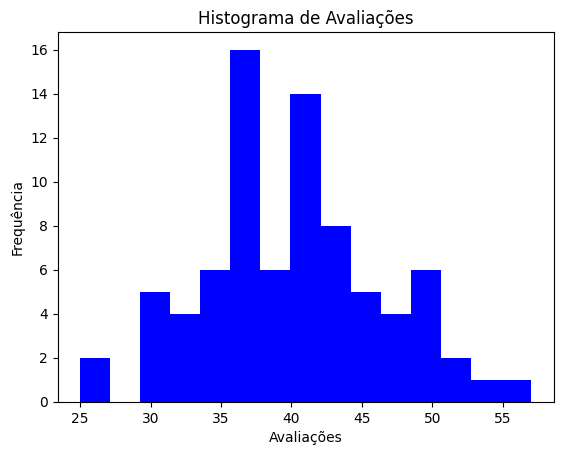

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_techtaste['avaliacoes'], bins=15, color='blue')
plt.xlabel('Avaliações')
plt.ylabel('Frequência')
plt.title('Histograma de Avaliações')
plt.show()

GRÁFICO PARA ANÁLISE VISUAL DA DISTRIBUIÇÃO

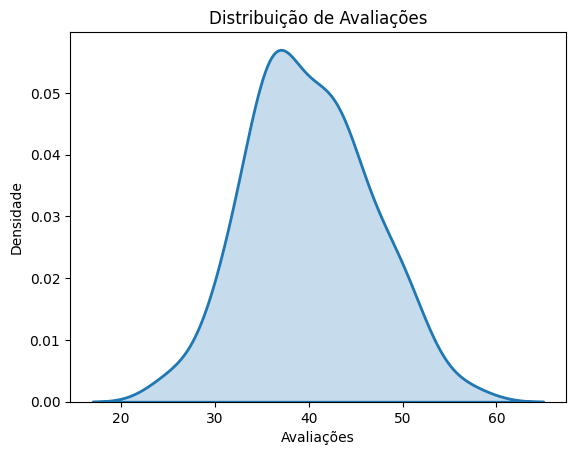

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_techtaste['avaliacoes'], linewidth=2, fill=True)
plt.xlabel('Avaliações')
plt.ylabel('Densidade')
plt.title('Distribuição de Avaliações')
plt.show()

CÁLCULO DO INTERVALO DE CONFIANÇA IC

In [ ]:
confianca = 0.90
intervalo_confianca = stats.norm.interval(confianca, loc=df_techtaste['avaliacoes'].mean(), scale=erro_padrao)
print(f'Intervalo de confiança: ({confianca*100}%){intervalo_confianca}')

Intervalo de confiança: (90.0%)(np.float64(38.84402439920928), np.float64(41.205975600790715))


LARGURA DO INTERVALO DE CONFIANÇA

In [ ]:
confianca = 0.95
largura_intervalo = stats.norm.interval(confianca, loc=df_techtaste['avaliacoes'].mean(), scale=erro_padrao)
print(f'Largura do intervalo de confiança ({confianca*100}%): {largura_intervalo}')

Largura do intervalo de confiança (95.0%): (np.float64(38.617780776207844), np.float64(41.43221922379215))


CÁLCULO DA MÉDIA AMOSTRAL DAS AVALIAÇÕES

In [ ]:
media_amostral = df_techtaste['avaliacoes'].mean()
print(f'Média amostral: {media_amostral:.2f}')

Média amostral: 40.02


FORMULAÇÃO DE HIPÓTESES PARA O PROBLEMA

In [ ]:
'''
H0: u = 30
H1: u != 30
'''

'\nH0: u = 30\nH1: u != 30\n'

MÉDIA DA AMOSTRA DENTRO DO IC COM NÍVEL DE CONFIANÇA DE 95% E DESVIO PADRÃO DE 2.65

In [ ]:
import numpy as np

confianca = 0.95
desvio_padrao_populacional = 2.65

tamanho_amostra = len(df_techtaste)
media_nula = 30

from scipy import stats
intervalo_confianca = stats.norm.interval(confianca, loc=media_nula, scale=desvio_padrao_populacional/np.sqrt(tamanho_amostra))

print(f'Intervalo de Confiança ({confianca*100}%): {intervalo_confianca}')

Intervalo de Confiança (95.0%): (np.float64(29.419303816868016), np.float64(30.580696183131984))


TESTE Z PARA CALCULAR O VALOR DA ESTATÍSTICA Z E O P_VALOR

In [ ]:
from statsmodels.stats.weightstats import ztest

stats, p_valor = ztest(df_techtaste['avaliacoes'], value=media_nula, alternative = 'two-sided')
print(f'Estatística Z: {stats:.2f}')
print(f'P-valor: {p_valor:.2f}')

Estatística Z: 13.96
P-valor: 0.00


HIPÓTESE NULA REJEITADA OU NÃO REJEITADA?

In [ ]:
nivel_significancia = 0.05

if p_valor < nivel_significancia:
  conclusao = 'Rejeitar a hipótese nula'
else:
  conclusao = 'Não rejeita a hipótese nula'

print('Conclusão:', conclusao)

Conclusão: Rejeitar a hipótese nula


PROJETO II

In [ ]:
import pandas as pd

# Conjunto de dados Techsafe
df_techsafe = pd.DataFrame({'porcentagem_compressao': [21.99342831, 20.7234714 , 22.29537708, 24.04605971, 20.53169325, 20.53172609, 24.15842563, 22.53486946, 20.06105123, 22.08512009, 20.07316461, 20.06854049, 21.48392454, 17.17343951, 17.55016433, 19.87542494, 18.97433776, 21.62849467, 19.18395185, 18.1753926, 23.93129754, 20.5484474 , 21.13505641, 18.15050363, 19.91123455]})

FORMULAÇÃO DE HIPÓTESE

In [ ]:
'''
H0: u = 20
H1: u > 20
'''

'\nH0: u = 20\nH1: u > 20\n'

CALCULO DA MEDIA AMOSTRAL

In [ ]:
media_amostral = df_techsafe['porcentagem_compressao'].mean()
print(f'Média amostral: {media_amostral:.2f}')

Média amostral: 20.67


NÍVEL DE CONFIANÇA E NÍVEL DE SIGNIFICÂNCIA

In [ ]:
nivel_confianca = 0.95
nivel_significancia = 1-nivel_confianca
print(f'Nível de confiança: {nivel_confianca}')
print(f'Nível de significância: {nivel_significancia}')

Nível de confiança: 0.95
Nível de significância: 0.050000000000000044


TESTE T PARA CÁLCULO DE VALOR DA ESTATÍSTICA E O P_VALOR

In [ ]:
from scipy.stats import ttest_1samp

valor_hipotese_nula = 20

estatistica_t, p_valor = ttest_1samp(df_techsafe['porcentagem_compressao'], valor_hipotese_nula, alternative = 'greater')
print(f'Estatística t: {estatistica_t:.2f}')
print(f'P-valor: {p_valor:.2f}')

Estatística t: 1.76
P-valor: 0.05


HIPÓTESE NULA REJEITADA OU NÃO REJEITADA?

In [ ]:
if p_valor < nivel_significancia:
  decisao = 'Rejeitar a hipotese nula'
  print(f'Conclusão: {decisao}')
else:
  decisao = 'Não rejeitar a hipotese nula'
  print(f'Conclusão: {decisao}')

Conclusão: Rejeitar a hipotese nula


PROJETO III - ZOOPMEGASTORE

In [ ]:
import pandas as pd

df_equipe_vendas = pd.DataFrame({'Vendedor': [ 'Luíza', 'Bia', 'Rodrigo', 'Allan', 'Evaldo'],
                                 'Vendas Antes (R$)': [252.72, 203.91, 307.32, 185.78, 220.5],
                                 'Vendas Depois (R$)': [285.1, 223.15, 324.41, 202.23, 240.63]})

TRATA-SE DE NATUREZA PAREADA  

FORMULAÇÃO DE HIPÓTESE

In [ ]:
'''
H0: u = 0
H1: u != 0
'''

'\nH0: u = 0\nH1: u != 0\n'

APLICAÇÃO DE TESTE PARAMÉTRICO

In [ ]:
from scipy.stats import ttest_rel

estatistica_t, p_valor = ttest_rel(df_equipe_vendas['Vendas Depois (R$)'], df_equipe_vendas['Vendas Antes (R$)'])
print(f'Estatística t: {estatistica_t}')
print(f'P-valor: {p_valor}')

Estatística t: 7.23705258430516
P-valor: 0.0019344230773580572


HIPÓTESE NULA REJEITADA OU NÃO REJEITADA?

In [ ]:
nivel_significancia = 0.05
if p_valor < nivel_significancia:
  decisao = 'Rejeitar a hipotese nula'
  print(f'Conclusão: {decisao}')
else:
  decisao = 'Não rejeitar a hipotese nula'
  print(f'Conclusão: {decisao}')

Conclusão: Rejeitar a hipotese nula


PROJETO IV - 1º CASO PLAYCATCH

In [ ]:
import pandas as pd

df_avaliacoes = pd.DataFrame({
    'playcatch': [4, 5, 3, 4, 5, 4, 4, 3, 5, 4, 5, 3, 4],
    'concorrente': [3, 4, 3, 3, 2, 4, 3, 2, 3, 3, 4, 2, 3]
})
df_avaliacoes

,playcatch,concorrente
0,4,3
1,5,4
2,3,3
3,4,3
4,5,2
5,4,4
6,4,3
7,3,2
8,5,3
9,4,3


FORMULAÇÃO DE HIPÓTESES

In [ ]:
'''
H0: Não há diferença significativa nas avaliações médias entre Playcatch e a concorrente.
H1: Há uma diferença significativa nas avaliações médias entre Playcatch e a concorrente.
'''

'\nH0: Não há diferença significativa nas avaliações médias entre Playcatch e a concorrente.\nH1: Há uma diferença significativa nas avaliações médias entre Playcatch e a concorrente.\n'

TESTE DE HIPÓTESE APROPRIADO PARA O CASO É TESTE MANN-WHITNEY

In [ ]:
from scipy.stats import mannwhitneyu

estatistica_u, p_valor = mannwhitneyu(df_avaliacoes['playcatch'], df_avaliacoes['concorrente'], alternative='two-sided')

print(f'Estatística U: {estatistica_u}')
print(f'P-valor: {p_valor}')

Estatística U: 140.5
P-valor: 0.0026661275820288304


HIPÓTESE NULA REJEITADA OU NÃO REJEITADA?

In [ ]:
nivel_significancia = 0.05

if p_valor < nivel_significancia:
  decisao = 'Rejeitar a hipótese nula'
else:
  decisao = 'Não rejeitar a hipótese nula'

print('Conclusão:', decisao)

Conclusão: Rejeitar a hipótese nula


PROJETO IV - 2º CASO PLAYCATCH

In [ ]:
import pandas as pd

df_wt = pd.DataFrame({
    'Antes_WatchTogether': [3, 4, 3, 4, 2, 4, 3, 2, 3, 3, 4, 2, 3],
    'Depois_WatchTogether': [4, 5, 3, 4, 5, 4, 4, 3, 5, 4, 5, 3, 4]
})

df_wt

,Antes_WatchTogether,Depois_WatchTogether
0,3,4
1,4,5
2,3,3
3,4,4
4,2,5
5,4,4
6,3,4
7,2,3
8,3,5
9,3,4


FORMULAÇÃO DE HIPÓTESES

In [ ]:
'''
H0: Não há diferença significativa nas avaliações médias antes e depois da introdução do WatchTogether (a mediana das diferenças entre os pares é zero).
H1: Há uma diferença significativa nas avaliações médias antes e depois da introdução do WatchTogether (a mediana das diferenças entre os pares é diferente de zero).
'''

'\nH0: Não há diferença significativa nas avaliações médias antes e depois da introdução do WatchTogether (a mediana das diferenças entre os pares é zero).\nH1: Há uma diferença significativa nas avaliações médias antes e depois da introdução do WatchTogether (a mediana das diferenças entre os pares é diferente de zero).\n'

TESTE DE HIPÓTESE APROPRIADO PARA O CASO É TESTE WILCOXON

In [ ]:
from scipy.stats import wilcoxon

stat, p_valor = wilcoxon(df_wt['Depois_WatchTogether'] - df_wt['Antes_WatchTogether'])

print(f'Estatística de Wilcoxon: {stat}')
print(f'P-valor: {p_valor}')

Estatística de Wilcoxon: 0.0
P-valor: 0.001953125


HIPÓTESE NULA REJEITADA OU NÃO REJEITADA?

In [ ]:
nivel_significancia = 0.05

if p_valor < nivel_significancia:
  conclusao = 'Hipótese nula rejeitada'
else:
  conclusão = 'Hipótese nula não rejeitada'

print(f'Conclusão: {conclusao}')

Conclusão: Hipótese nula rejeitada
